In [2]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from collections          import Counter
from Algorithm            import KMEANS
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca
from utils import Kmeans_silhouette_analysis,Kmeans_davies_bouldin_analysis,Kmeans_Inertia_analysis


In [3]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
print(data.shape)
print(data.head(1))

(1898, 3)
    balance  purchases  cash_advance
0 -1.594479  -0.275098     -0.926725


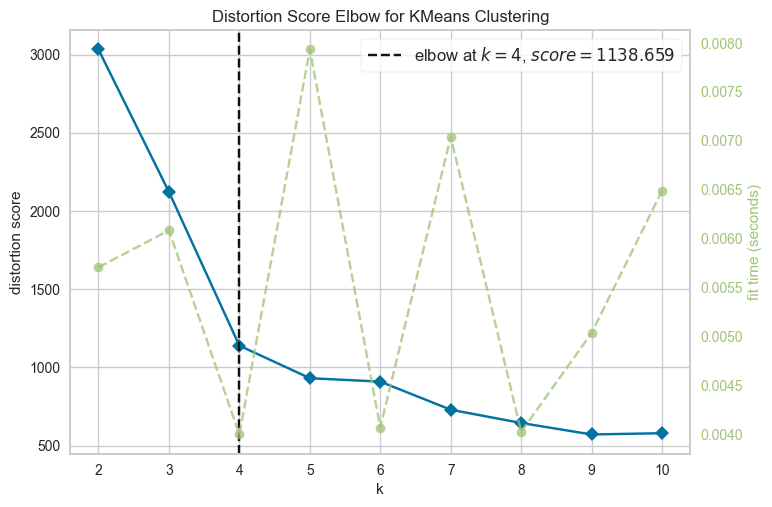

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [8]:
El=KElbowVisualizer(KMeans(),k=10)
El.fit(data)
El.show()

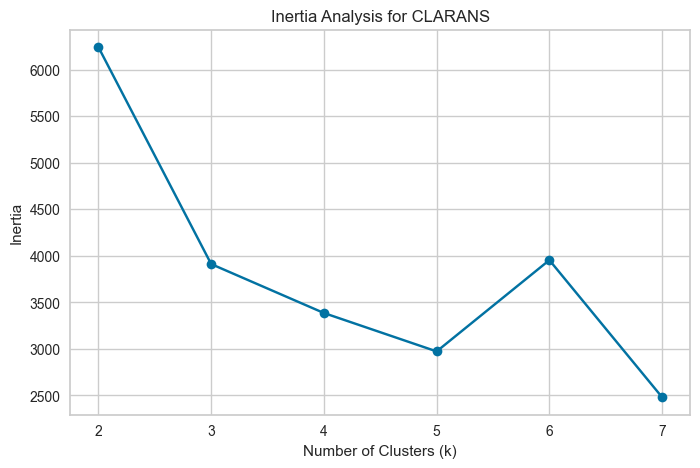

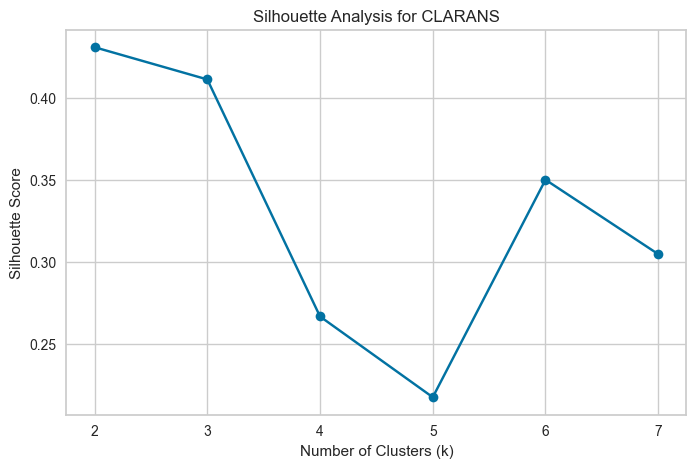

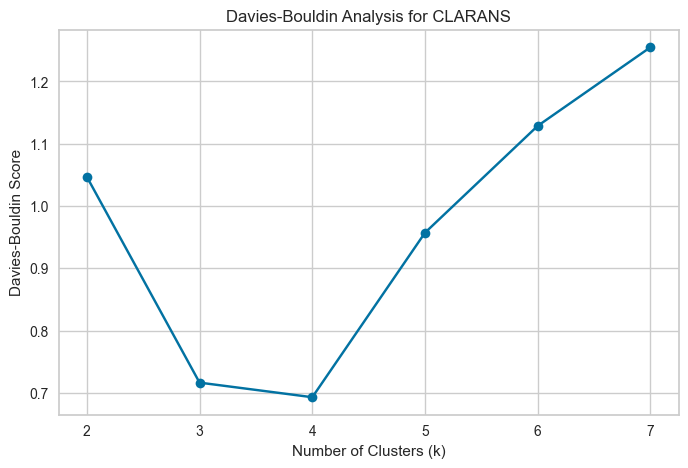

In [9]:
Kmeans_Inertia_analysis(data, k_range=range(2, 8))
Kmeans_silhouette_analysis(data, k_range=range(2, 8))
Kmeans_davies_bouldin_analysis(data, k_range=range(2, 8))

In [8]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 4
Kmeans_model = KMEANS(data,n_clusters = k)
(ticks,results) = timedcall(Kmeans_model.fit)  # xây dựng mô hình
print(f"Thời gian chạy: {ticks:.4f} giây")

Thời gian chạy: 0.1006 giây


In [9]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [10]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [11]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.get_centroids())

*** 4 trọng tâm:
[[-0.06999579  0.74410554 -0.92672452]
 [ 0.68904139 -0.20601671  1.7655263 ]
 [ 1.14640376  1.15505062 -0.92672452]
 [ 1.02483497 -1.83607871  0.91355741]]


In [12]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.get_centroids()
data['cluster'] = Loaded_Kmeans_model.get_labels()
print(data.head(5))
print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.get_labels()))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.get_labels()).most_common(1))

    balance  purchases  cash_advance  cluster
0 -1.594479  -0.275098     -0.926725        0
1  0.746068  -1.836079      1.487937        3
2  0.611419   0.436726     -0.926725        0
3  0.009768  -0.868018     -0.926725        0
4  0.438191   0.622723     -0.926725        0

Kích thước các clusters: Counter({np.int64(0): 918, np.int64(1): 452, np.int64(3): 375, np.int64(2): 153})

Clusters lớn nhất: [(np.int64(0), 918)]


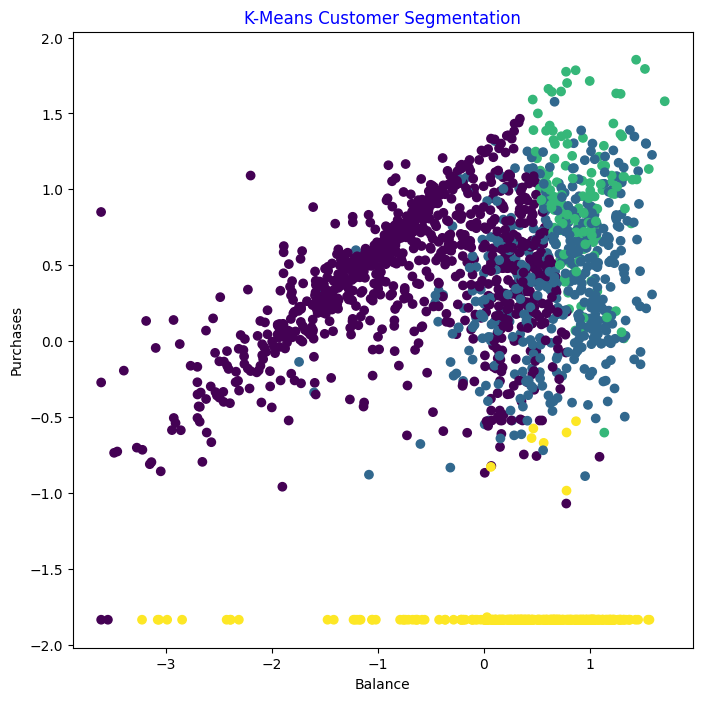

In [13]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(
    data['balance'],
    data['purchases'],
    c=data['cluster']
)
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()

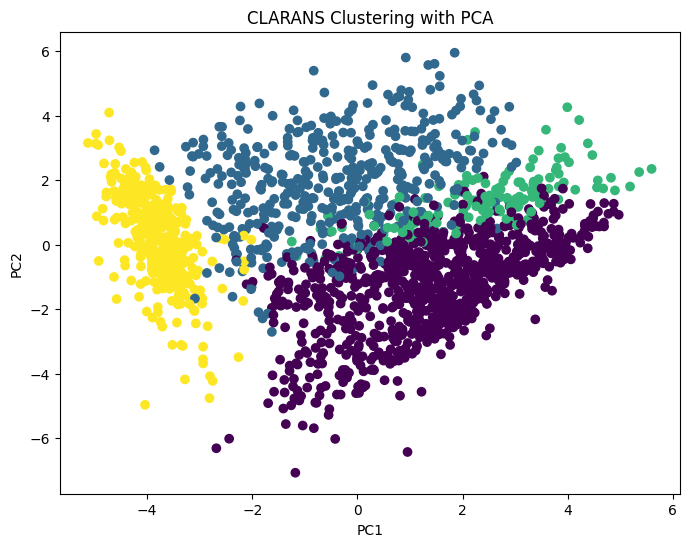

In [14]:

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=data['cluster'])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()